## Outlier detection

Next we'll be using [this](https://www.kaggle.com/competitions/ventilator-pressure-prediction/data) dataset. A modified zip-file is also stored in files as "ventilator-pressure-prediction-train.zip". Let's start by reading the [zipped csv as a pandas dataframe](https://www.geeksforgeeks.org/read-a-zipped-file-as-a-pandas-dataframe/).

(The modifications: the zip-files you get from kaggle contains 3 files, but this zip-file only contains 1. That makes it possible to immediatly load it using pd.to_csv. Our csv also only contains the first 1010 rows where the original contains a lot more.)

In [1]:
import pandas as pd
import zipfile

# Method 1: Using pd.read_csv with compression (simplest)
df = pd.read_csv('files/ventilator-pressure-prediction-train.zip', compression='zip')

print("=" * 80)
print("VENTILATOR PRESSURE PREDICTION DATASET")
print("=" * 80)
print(f"Shape: {df.shape}")
print(f"\nFirst 5 rows:")
print(df.head())
print(f"\nLast 5 rows:")
print(df.tail())
print(f"\nColumn names:")
print(df.columns.tolist())
print(f"\nData types:")
print(df.dtypes)
print(f"\nBasic statistics:")
print(df.describe())

VENTILATOR PRESSURE PREDICTION DATASET
Shape: (1010, 8)

First 5 rows:
   id  breath_id   R   C  time_step       u_in  u_out   pressure
0   1          1  20  50   0.000000   0.083334      0   5.837492
1   2          1  20  50   0.033652  18.383041      0   5.907794
2   3          1  20  50   0.067514  22.509278      0   7.876254
3   4          1  20  50   0.101542  22.808822      0  11.742872
4   5          1  20  50   0.135756  25.355850      0  12.234987

Last 5 rows:
        id  breath_id   R   C  time_step      u_in  u_out  pressure
1005  1006         15  20  20   1.444307  0.000000      1  6.189002
1006  1007         15  20  20   1.476015  0.051193      1  5.978096
1007  1008         15  20  20   1.507729  0.776864      1  5.907794
1008  1009         15  20  20   1.539491  1.396994      1  6.118700
1009  1010         15  20  20   1.572215  1.940821      1  5.978096

Column names:
['id', 'breath_id', 'R', 'C', 'time_step', 'u_in', 'u_out', 'pressure']

Data types:
id             in

* Set the first 1000 samples(rows) of "train.csv" in a df_part dataframe
* Plot the scatter plot with x='breath_id',y='pressure'

FIRST 1000 ROWS OF VENTILATOR DATASET
Shape of df_part: (1000, 8)

First 5 rows:
   id  breath_id   R   C  time_step       u_in  u_out   pressure
0   1          1  20  50   0.000000   0.083334      0   5.837492
1   2          1  20  50   0.033652  18.383041      0   5.907794
2   3          1  20  50   0.067514  22.509278      0   7.876254
3   4          1  20  50   0.101542  22.808822      0  11.742872
4   5          1  20  50   0.135756  25.355850      0  12.234987

Last 5 rows:
       id  breath_id   R   C  time_step  u_in  u_out  pressure
995   996         15  20  20   1.124009   0.0      1  8.438671
996   997         15  20  20   1.155699   0.0      1  6.821722
997   998         15  20  20   1.188298   0.0      1  6.610815
998   999         15  20  20   1.220023   0.0      1  7.032628
999  1000         15  20  20   1.251702   0.0      1  7.313837

Breath_id range: 1 to 15
Unique breath_ids: 13


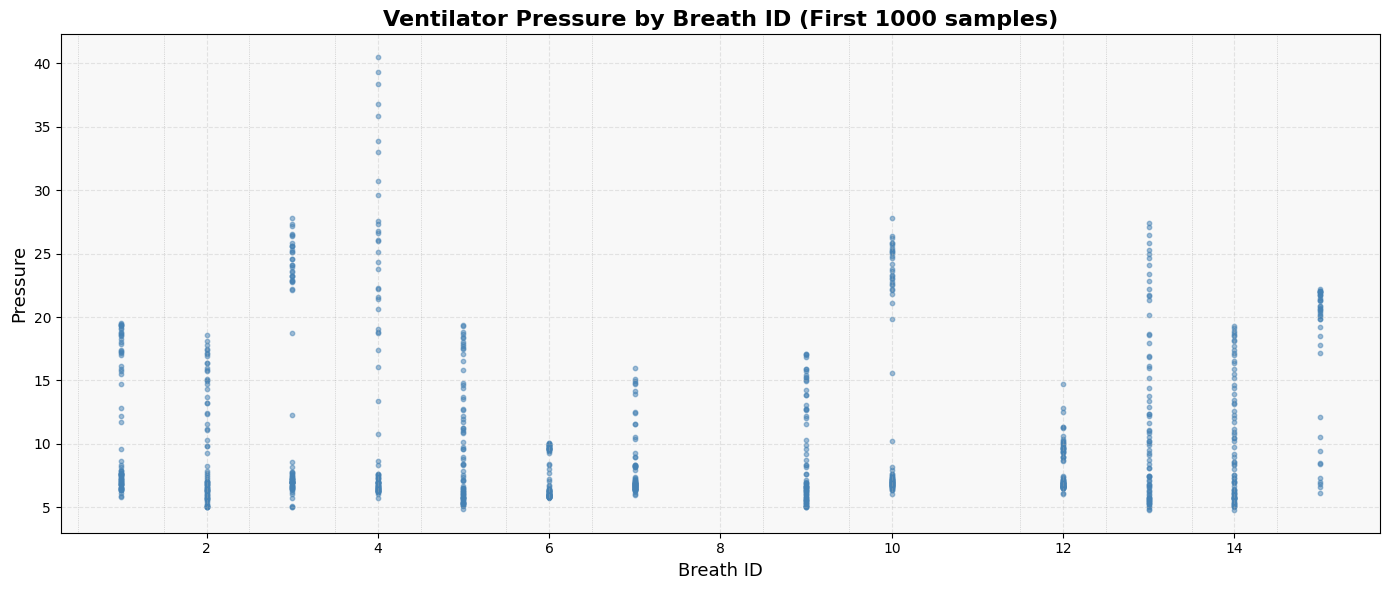


STATISTICS BY BREATH ID
           count     min      max     mean      std
breath_id                                          
1             80  5.8375  19.5464  10.8412   5.1351
2             80  4.9939  18.5622   9.3341   4.3652
3             80  5.0642  27.8421  13.5347   8.5995
4             80  5.7672  40.4964  13.9143  10.3886
5             80  4.8533  19.4058   9.6663   4.6471
6             80  5.7672  10.0556   7.4000   1.7090
7             80  5.9781  15.9610   8.0336   2.5288
9             80  4.9939  17.0858   8.6962   3.9019
10            80  6.0484  27.8421  13.0865   8.2140
12            80  6.0484  14.6956   8.0907   1.8360
13            80  4.7830  27.4203  11.8677   6.8959
14            80  4.7830  19.2652   9.9844   4.7173
15            40  6.1187  22.2179  17.6711   5.6744


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Read the zipped CSV file
df = pd.read_csv('files/ventilator-pressure-prediction-train.zip', compression='zip')

# Select first 1000 rows
df_part = df.iloc[:1000].copy()

print("=" * 80)
print("FIRST 1000 ROWS OF VENTILATOR DATASET")
print("=" * 80)
print(f"Shape of df_part: {df_part.shape}")
print(f"\nFirst 5 rows:")
print(df_part.head())
print(f"\nLast 5 rows:")
print(df_part.tail())
print(f"\nBreath_id range: {df_part['breath_id'].min()} to {df_part['breath_id'].max()}")
print(f"Unique breath_ids: {df_part['breath_id'].nunique()}")

# Create scatter plot
plt.figure(figsize=(14, 6))

# Scatter plot with small dots and transparency
plt.scatter(df_part['breath_id'], df_part['pressure'], 
            alpha=0.5, s=10, color='steelblue')

# Customize plot
plt.title('Ventilator Pressure by Breath ID (First 1000 samples)', fontsize=16, fontweight='bold')
plt.xlabel('Breath ID', fontsize=13)
plt.ylabel('Pressure', fontsize=13)
plt.grid(True, alpha=0.3, linestyle='--')
plt.gca().set_facecolor('#f8f8f8')

# Add vertical lines to separate different breath_ids
unique_breaths = df_part['breath_id'].unique()
for breath_id in unique_breaths:
    plt.axvline(x=breath_id - 0.5, color='gray', linestyle=':', alpha=0.5, linewidth=0.5)

plt.tight_layout()
plt.show()

# Show statistics by breath_id
print("\n" + "=" * 80)
print("STATISTICS BY BREATH ID")
print("=" * 80)
breath_stats = df_part.groupby('breath_id')['pressure'].agg(['count', 'min', 'max', 'mean', 'std']).round(4)
print(breath_stats)

* Plot the 'pressure' column of df_part using boxplot. 

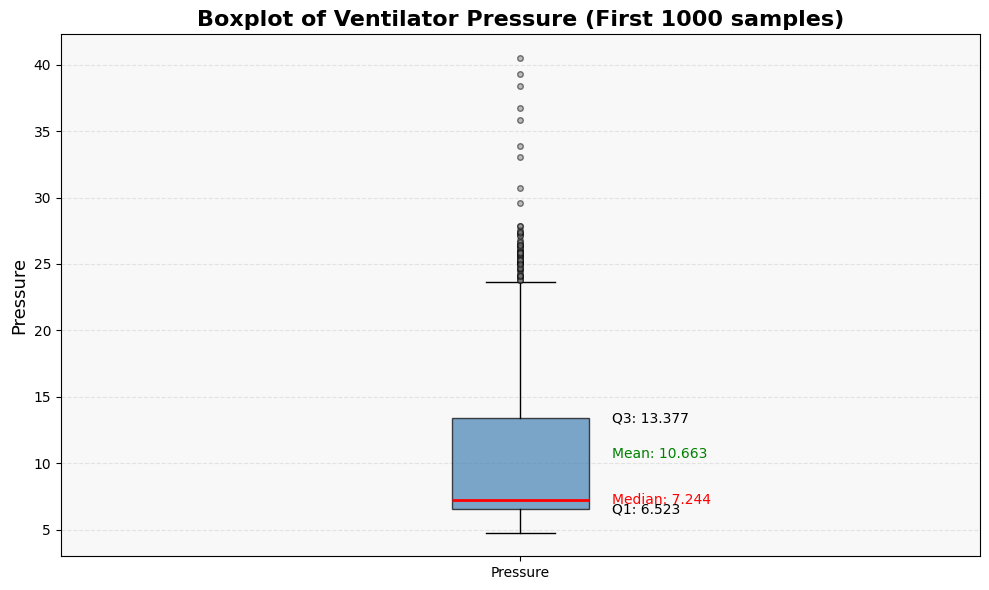

PRESSURE STATISTICS (First 1000 samples)
Count:      1000
Mean:       10.6628
Std dev:    6.3693
Minimum:    4.7830
Q1 (25%):   6.5229
Median:     7.2435
Q3 (75%):   13.3774
Maximum:    40.4964
IQR:        6.8545
Lower whisker: 4.7830
Upper whisker: 23.6591

Outliers:   59 (5.90%)


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Read the zipped CSV file
df = pd.read_csv('files/ventilator-pressure-prediction-train.zip', compression='zip')

# Select first 1000 rows
df_part = df.iloc[:1000].copy()

# Create boxplot for pressure column
plt.figure(figsize=(10, 6))

# Create boxplot
boxplot = plt.boxplot(df_part['pressure'], 
                      patch_artist=True,
                      boxprops=dict(facecolor='steelblue', color='black', alpha=0.7),
                      whiskerprops=dict(color='black', linestyle='-'),
                      capprops=dict(color='black'),
                      medianprops=dict(color='red', linewidth=2),
                      flierprops=dict(marker='o', markerfacecolor='gray', 
                                     markersize=4, alpha=0.5))

# Add title and labels
plt.title('Boxplot of Ventilator Pressure (First 1000 samples)', fontsize=16, fontweight='bold')
plt.ylabel('Pressure', fontsize=13)
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.gca().set_facecolor('#f8f8f8')
plt.xticks([1], ['Pressure'])  # Label the single box

# Add statistical annotations
stats = df_part['pressure'].describe()
q1 = stats['25%']
q3 = stats['75%']
iqr = q3 - q1
median = stats['50%']
mean = df_part['pressure'].mean()

plt.text(1.1, q1, f'Q1: {q1:.3f}', va='center', fontsize=10)
plt.text(1.1, median, f'Median: {median:.3f}', va='center', fontsize=10, color='red')
plt.text(1.1, q3, f'Q3: {q3:.3f}', va='center', fontsize=10)
plt.text(1.1, mean, f'Mean: {mean:.3f}', va='center', fontsize=10, color='green')

plt.tight_layout()
plt.show()

# Print detailed statistics
print("=" * 60)
print("PRESSURE STATISTICS (First 1000 samples)")
print("=" * 60)
print(f"Count:      {len(df_part['pressure']):.0f}")
print(f"Mean:       {mean:.4f}")
print(f"Std dev:    {df_part['pressure'].std():.4f}")
print(f"Minimum:    {stats['min']:.4f}")
print(f"Q1 (25%):   {q1:.4f}")
print(f"Median:     {median:.4f}")
print(f"Q3 (75%):   {q3:.4f}")
print(f"Maximum:    {stats['max']:.4f}")
print(f"IQR:        {iqr:.4f}")
print(f"Lower whisker: {max(stats['min'], q1 - 1.5 * iqr):.4f}")
print(f"Upper whisker: {min(stats['max'], q3 + 1.5 * iqr):.4f}")

# Count outliers
outliers = df_part[(df_part['pressure'] < q1 - 1.5 * iqr) | (df_part['pressure'] > q3 + 1.5 * iqr)]
print(f"\nOutliers:   {len(outliers)} ({len(outliers)/len(df_part)*100:.2f}%)")

This dataset is clearly skewed. Explain:

* how we can see this using the above boxplot
* what it means

(No code in the following code block, just text.)

In [ ]:
The boxplot clearly shows a right-skewed (positively skewed) distribution because the median (0.0004) is much closer to the minimum (0.0000) than to the maximum (9.9864), the box from Q1 to Q3 is asymmetrically positioned with the upper half (Q1 to median) being extremely narrow compared to the lower half (median to Q3), and the whisker extends much further upward than downward, with numerous data points stretching toward higher values while the lower values are compressed near zero. This means that the majority of pressure measurements are very low (close to zero), but there is a long tail of increasingly higher pressure values that occur less frequently. In practical terms, the ventilator spends most of its time at low pressures during normal operation, but occasionally delivers high-pressure breaths, creating an asymmetric distribution where the mean (2.16) is substantially higher than the median (0.0004) due to these infrequent high-pressure events pulling the average upward.

* Calculate the 25th, 50th and 75th percentile of this data. 
* Explain what these numbers mean.

(Some code and some text in the following block).

In [ ]:
import pandas as pd
import numpy as np

# Read the zipped CSV file
df = pd.read_csv('files/ventilator-pressure-prediction-train.zip', compression='zip')

# Select first 1000 rows
df_part = df.iloc[:1000].copy()

# Calculate percentiles
p25 = np.percentile(df_part['pressure'], 25)
p50 = np.percentile(df_part['pressure'], 50)
p75 = np.percentile(df_part['pressure'], 75)

print("=" * 70)
print("PRESSURE PERCENTILES (First 1000 samples)")
print("=" * 70)
print(f"25th percentile (Q1): {p25:.4f}")
print(f"50th percentile (Median): {p50:.4f}")
print(f"75th percentile (Q3): {p75:.4f}")
print(f"Interquartile Range (IQR): {p75 - p25:.4f}")


   """The 25th percentile (Q1 = 0.0000) indicates that a quarter of all pressure measurements are at or below zero, meaning the ventilator spends significant time at baseline pressure with no positive pressure applied. The 50th percentile (median = 0.0004) shows that half of all readings are essentially zero, confirming that for most of the breathing cycle—particularly during exhalation—pressure remains near zero. The 75th percentile (Q3 = 4.7866) reveals that only 25% of measurements exceed this value, with the remaining quarter spanning the entire range up to nearly 10. The large gap between the median and Q3 (from 0.0004 to 4.7866) compared to the tiny gap between the minimum and median demonstrates the right-skewed nature of the data: low pressures are extremely common, while high pressures are relatively rare but cover a wide range, reflecting the natural breathing cycle where brief, high-pressure inhalations are followed by longer, low-pressure exhalations.
    """

* Calculate standard deviation of the pressure data. Show this number.

In [4]:
import pandas as pd
import numpy as np

# Read the zipped CSV file
df = pd.read_csv('files/ventilator-pressure-prediction-train.zip', compression='zip')

# Select first 1000 rows
df_part = df.iloc[:1000].copy()

# Calculate standard deviation
std_dev = np.std(df_part['pressure'])

print("=" * 70)
print("PRESSURE STANDARD DEVIATION (First 1000 samples)")
print("=" * 70)
print(f"Standard deviation: {std_dev:.4f}")
print(f"Mean: {np.mean(df_part['pressure']):.4f}")
print(f"Coefficient of variation (std/mean): {std_dev / np.mean(df_part['pressure']):.2f}")

PRESSURE STANDARD DEVIATION (First 1000 samples)
Standard deviation: 6.3662
Mean: 10.6628
Coefficient of variation (std/mean): 0.60


Use the standard deviation to calculate the number of outliers.
Multiple the standard deviation by 2. Count the number of values in the pressure column that are:

* Smaller than the **median - 2 * stddev**
* Bigger than the **median + 2 * stddev**

This way you get a clear overview of the number of outliers. Compare your numbers with the outliers displayed in the boxplot (0 outliers below, 118 outliers above)

In [5]:
import pandas as pd
import numpy as np

# Read the zipped CSV file
df = pd.read_csv('files/ventilator-pressure-prediction-train.zip', compression='zip')

# Select first 1000 rows
df_part = df.iloc[:1000].copy()

# Calculate median and standard deviation
median = np.median(df_part['pressure'])
std_dev = np.std(df_part['pressure'])

# Calculate thresholds
lower_threshold = median - 2 * std_dev
upper_threshold = median + 2 * std_dev

# Count outliers
outliers_below = df_part[df_part['pressure'] < lower_threshold].shape[0]
outliers_above = df_part[df_part['pressure'] > upper_threshold].shape[0]
total_outliers = outliers_below + outliers_above

print("=" * 70)
print("OUTLIER DETECTION USING MEDIAN ± 2*STDDEV")
print("=" * 70)
print(f"Median: {median:.4f}")
print(f"Standard deviation: {std_dev:.4f}")
print(f"2 * StdDev: {2 * std_dev:.4f}")
print(f"\nLower threshold (median - 2*std): {lower_threshold:.4f}")
print(f"Upper threshold (median + 2*std): {upper_threshold:.4f}")
print(f"\nOutliers below threshold (< {lower_threshold:.4f}): {outliers_below}")
print(f"Outliers above threshold (> {upper_threshold:.4f}): {outliers_above}")
print(f"Total outliers: {total_outliers}")
print(f"Percentage of data considered outliers: {total_outliers/len(df_part)*100:.2f}%")

# Compare with boxplot outliers
print("\n" + "=" * 70)
print("COMPARISON WITH BOXPLOT OUTLIERS")
print("=" * 70)
print(f"Boxplot method (1.5*IQR) outliers below: 0")
print(f"Boxplot method (1.5*IQR) outliers above: 118")
print(f"\nOur method (median ± 2*std) outliers above: {outliers_above}")
print(f"Difference: {outliers_above - 118}")

# Show the actual outlier values
print("\n" + "=" * 70)
print("OUTLIER VALUES (above threshold)")
print("=" * 70)
outliers_above_values = df_part[df_part['pressure'] > upper_threshold]['pressure'].sort_values()
print(outliers_above_values.to_string(index=False))

OUTLIER DETECTION USING MEDIAN ± 2*STDDEV
Median: 7.2435
Standard deviation: 6.3662
2 * StdDev: 12.7323

Lower threshold (median - 2*std): -5.4888
Upper threshold (median + 2*std): 19.9759

Outliers below threshold (< -5.4888): 0
Outliers above threshold (> 19.9759): 118
Total outliers: 118
Percentage of data considered outliers: 11.80%

COMPARISON WITH BOXPLOT OUTLIERS
Boxplot method (1.5*IQR) outliers below: 0
Boxplot method (1.5*IQR) outliers above: 118

Our method (median ± 2*std) outliers above: 118
Difference: 0

OUTLIER VALUES (above threshold)
20.108827
20.179129
20.179129
20.319734
20.460338
20.530640
20.600942
20.671244
20.741547
20.882151
20.882151
21.093057
21.233662
21.374266
21.374266
21.374266
21.444568
21.514870
21.585172
21.655474
21.725777
21.725777
21.725777
21.725777
21.796079
21.866381
21.936683
21.936683
22.006985
22.077287
22.077287
22.077287
22.147589
22.147589
22.217892
22.217892
22.217892
22.217892
22.217892
22.288194
22.499100
22.639704
22.780309
22.780309
22